In [1]:
import numpy as np
from scipy import optimize
from scipy import interpolate
import pickle as pkl
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

**Reminder:** My goal is to see/analyze/study how the eccentricities of these binaries is/behaves once the system has gotten to the point where the GWs have a (detectable) frequency of around 10 Hz. The average evolution rates of the binary semi-major axis and eccentricity do not change with time, and so they can be applied to this binary state. 

**Magda's data**

In [2]:
fl = open(r'C:\Users\samra\Documents\Summer2023_BHB_Research\ebdot_abdot_tmin3000Pb_tmax10000Pb.pkl', 'rb')
abdot_ebdot = pkl.load(fl)

abdot_ebdot
#abdot_ebdot.keys()
#abdot_ebdot.values()

#Eccentricities range from [0.0,0.8] and semimajor axis values range from [0.1,1.0]

#NOTE: _eb_dot = eccentricity evolution, _ab_dot = semimajor axis evolution, _mdot = mass evolution (?)

{'e=0.00_q=0.10_mdot_1': 3.428588904482091e-08,
 'e=0.00_q=0.10_mdot_2': 2.1080116671713235e-07,
 'e=0.00_q=0.10_mdot': 2.4508705576195314e-07,
 'e=0.00_q=0.10_eb_dot_sum_grav': 3.493857925891689e-05,
 'e=0.00_q=0.10_eb_dot_sum_grav_a': 3.493857925892428e-05,
 'e=0.00_q=0.10_eb_dot_sum_grav_acc': 3.488635249010523e-05,
 'e=0.00_q=0.10_ab_dot_ab_sum_grav': -1.2808309487849858,
 'e=0.00_q=0.10_ab_dot_ab_sum_grav_a': -8.856453704247176,
 'e=0.00_q=0.10_ab_dot_ab_sum_grav_acc': -1.2588927484346075,
 'e=0.00_q=0.10_eb_dot_f_inst_grav': -0.05504041622042038,
 'e=0.00_q=0.10_eb_dot_f_inst_grav_a': -0.09681113974210095,
 'e=0.00_q=0.10_eb_dot_f_inst_grav_acc': 5.48750698385851e-05,
 'e=0.00_q=0.10_ab_dot_ab_f_inst_grav': -1.3404924818047976,
 'e=0.00_q=0.10_ab_dot_ab_f_inst_grav_a': -8.953236040861144,
 'e=0.00_q=0.10_ab_dot_ab_f_inst_grav_acc': -0.9664997807888172,
 'e=0.00_q=0.20_mdot_1': 4.7865889806649316e-08,
 'e=0.00_q=0.20_mdot_2': 1.9489142412242927e-07,
 'e=0.00_q=0.20_mdot': 2.427573

In [3]:
# This gets the dictionary keys&values for only the eccentricity and semi-major axis evolution rates we want ("sum_grav_acc"),
# so that we can later use them.


filter_string1 = 'eb_dot_sum_grav_acc'
ecc_evo_dict = {k:v for k,v in abdot_ebdot.items() if filter_string1 in k}
print(ecc_evo_dict)                    # This prints out the filtered dictionary
#print(ecc_evo_dict.keys())            # This prints out the corresponding keys
#print(ecc_evo_dict.values())          # This prints out the corresponding values
#print(len(ecc_evo_dict))              # This prints out the length of the dictionary


filter_string2 = 'ab_dot_ab_sum_grav_acc'
semi_maj_evo_dict = {k:v for k,v in abdot_ebdot.items() if filter_string2 in k}
print(semi_maj_evo_dict)               # This prints out the filtered dictionary
#print(semi_maj_evo_dict.keys())       # This prints out the corresponding keys
#print(semi_maj_evo_dict.values())     # This prints out the corresponding values
#print(len(semi_maj_evo_dict))         # This prints out the length of the dictionary

{'e=0.00_q=0.10_eb_dot_sum_grav_acc': 3.488635249010523e-05, 'e=0.00_q=0.20_eb_dot_sum_grav_acc': 7.442294134508703e-06, 'e=0.00_q=0.30_eb_dot_sum_grav_acc': 1.6933772285208686e-05, 'e=0.00_q=0.40_eb_dot_sum_grav_acc': 9.298533107418273e-06, 'e=0.00_q=0.50_eb_dot_sum_grav_acc': -8.878210719378644e-06, 'e=0.00_q=0.60_eb_dot_sum_grav_acc': 1.9557428804050647e-05, 'e=0.00_q=0.70_eb_dot_sum_grav_acc': 1.0281107471336626e-05, 'e=0.00_q=0.80_eb_dot_sum_grav_acc': -3.088926860884904e-05, 'e=0.00_q=0.90_eb_dot_sum_grav_acc': -8.539577730279929e-07, 'e=0.00_q=1.00_eb_dot_sum_grav_acc': 1.871404863945317e-05, 'e=0.02_q=1.00_eb_dot_sum_grav_acc': 0.3743280300991139, 'e=0.03_q=1.00_eb_dot_sum_grav_acc': 0.47382997856152176, 'e=0.04_q=1.00_eb_dot_sum_grav_acc': 0.5355490843846645, 'e=0.05_q=0.10_eb_dot_sum_grav_acc': -0.4684303050118692, 'e=0.05_q=0.20_eb_dot_sum_grav_acc': 0.02263375780103669, 'e=0.05_q=0.30_eb_dot_sum_grav_acc': 0.13470403236369005, 'e=0.05_q=0.40_eb_dot_sum_grav_acc': 0.54277396

In [4]:
# Second filter to reduce the initial dictionary to values of all eccentricities, but only one chosen mass ratio at a time.

filter2_string1 = 'q=1.00'

changing_ecc_q_1 = {k:v for k,v in ecc_evo_dict.items() if filter2_string1 in k}
print(changing_ecc_q_1)                          # This prints out the filtered dictionary
#print(changing_ecc_q_1.keys())                  # This prints out the corresponding key
#print(list(changing_ecc_q_1.values()))          # This prints out the corresponding value
#print(len(list(changing_ecc_q_1.values())))

changing_semi_maj_q_1 = {k:v for k,v in semi_maj_evo_dict.items() if filter2_string1 in k}
print(changing_semi_maj_q_1)                          # This prints out the filtered dictionary
#print(changing_semi_maj_q_1.keys())                  # This prints out the corresponding key
#print(list(changing_semi_maj_q_1.values()))          # This prints out the corresponding value

{'e=0.00_q=1.00_eb_dot_sum_grav_acc': 1.871404863945317e-05, 'e=0.02_q=1.00_eb_dot_sum_grav_acc': 0.3743280300991139, 'e=0.03_q=1.00_eb_dot_sum_grav_acc': 0.47382997856152176, 'e=0.04_q=1.00_eb_dot_sum_grav_acc': 0.5355490843846645, 'e=0.05_q=1.00_eb_dot_sum_grav_acc': 0.692091816898143, 'e=0.10_q=1.00_eb_dot_sum_grav_acc': 5.406401814667789, 'e=0.20_q=1.00_eb_dot_sum_grav_acc': 7.188775573084456, 'e=0.30_q=1.00_eb_dot_sum_grav_acc': 9.521288212023046, 'e=0.40_q=1.00_eb_dot_sum_grav_acc': 6.933509837783115, 'e=0.50_q=1.00_eb_dot_sum_grav_acc': -1.8569328012861426, 'e=0.60_q=1.00_eb_dot_sum_grav_acc': -2.122080860608072, 'e=0.80_q=1.00_eb_dot_sum_grav_acc': -1.818735569936334}
{'e=0.00_q=1.00_ab_dot_ab_sum_grav_acc': 1.7534726250735466, 'e=0.02_q=1.00_ab_dot_ab_sum_grav_acc': 1.7002876283117645, 'e=0.03_q=1.00_ab_dot_ab_sum_grav_acc': 1.6081955329524986, 'e=0.04_q=1.00_ab_dot_ab_sum_grav_acc': 1.5595213761160105, 'e=0.05_q=1.00_ab_dot_ab_sum_grav_acc': 1.540844661306394, 'e=0.10_q=1.00_

In [5]:
test1 = list(changing_ecc_q_1.values())[11]     
test2 = list(changing_semi_maj_q_1.values())[11]

print(test1)
print(test2)

-1.818735569936334
-2.892418724373073


In [6]:
# TEST CELL, THIS CODE IS USED LATER IN NOTEBOOK
test_new = 0.12321
#search_key = str(test_new)
good_index = []

brute_force_list = [0.00,0.02,0.03,0.04,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.80]

for i in brute_force_list:
    if test_new < i:
        good_index.append(brute_force_list.index(i)-1)
    elif 0.8 <= test_new <= 1.0 :
        good_index.append(brute_force_list.index(0.80))

# This returns the index of the closest eccentricity smaller than the current evolving eccentricity
print(good_index)
final_good_index = min(good_index) 
print(list(changing_ecc_q_1.values())[final_good_index])

[5, 6, 7, 8, 9, 10]
5.406401814667789


In [7]:
# This is a third filter to select which initial eccentricity and semi-major axis evolution rate values we want, and the
# corresponding eccentricity and semi-major evolution rates. Note that we are filtering on the already filtered dictionary from
# the previous cell. We get the rate values for the eccentricity and semi-major axis evolution
# (in units of Accretion Rate/Binary Mass)

filter3_string2 = 'e=0.02_q=1.00'

ecc_evo_chosen = {k:v for k,v in ecc_evo_dict.items() if filter3_string2 in k}
print(ecc_evo_chosen)                  
#print(ecc_evo_chosen.keys())         
print(list(ecc_evo_chosen.values()))  

semi_maj_evo_chosen = {k:v for k,v in semi_maj_evo_dict.items() if filter3_string2 in k}
print(semi_maj_evo_chosen)                 
#print(semi_maj_evo_chosen.keys())         
print(list(semi_maj_evo_chosen.values())) 

{'e=0.02_q=1.00_eb_dot_sum_grav_acc': 0.3743280300991139}
[0.3743280300991139]
{'e=0.02_q=1.00_ab_dot_ab_sum_grav_acc': 1.7002876283117645}
[1.7002876283117645]


**Isobel's code part 2 (NON-ROTATING SYSTEMS GENERALLY)**

In [8]:
def sigma(e):
    frac = e**(12.0/19.0) / (1-e**2)
    return frac * (1 + (121.0*e**2)/304)**(870.0/2299)

def frequencyEccentricityRoot(eGuess, e0, f, f0):
    sigma0 = sigma(e0)
    sigmaGuess = sigma(eGuess)
    return f - f0 * (sigma0/sigmaGuess)**(3.0/2.0)

def smartShift(f, e0, f_ref, scalar=False):
    if scalar:
        e_new = optimize.brentq(frequencyEccentricityRoot, 1e-16, 1-1e-16, args=(e0, f, f_ref))

    # Vector arithmetic
    # Solve for e in a(e) = a_new
    else:
        e_new = optimize.root(frequencyEccentricityRoot, e0, args=(e0, f, f_ref), tol=1e-10).x
    return e_new

In [9]:
f_target = 10    #target binary frequency     (we want to see what the binary's eccentricity is at this frequency)
f_ref = 20       #reference binary frequency  
e_at_f_ref = 0.3  #binary eccentricity at reference frequency (we know this eccentricity already)

e_new = smartShift(f=f_target, e0=e_at_f_ref, f_ref=f_ref)
print("e: {} at f_target: {} Hz".format(e_new, f_target))


# In function set f_ref to the previous GW frequency in evolution, f_target is the desired "next" frequency, NOTE that the
# GW freq and semi maj evo rate are both changing at each timestep, so update that. Also, eccentricity at f_ref is consequently
# changing so update that too. NOTE: the first f_ref is the initial GW freq I calculate using my initial semi major axis value

# So, example using my main setup: e = 0.30, f_ref = 2.765e-7 (see cell below), so 

e: [0.47174292] at f_target: 10 Hz


In [10]:
# TEST CELL FOR FREQS

f_target = 10                   # target binary frequency   (we want to see what the binary's eccentricity is at this frequency)
f_ref = 2.7653281209100213e-07  # reference binary frequency  
e_at_f_ref = 0.5                # binary eccentricity at reference frequency (we know this eccentricity already)

e_new = smartShift(f=f_target, e0=e_at_f_ref, f_ref=f_ref)
print("e: {} at f_target: {} Hz".format(e_new, f_target))

e: [0.5] at f_target: 10 Hz


C:\Users\samra\AppData\Local\Temp\ipykernel_11040\2513534886.py:2: RuntimeWarning: invalid value encountered in power
  frac = e**(12.0/19.0) / (1-e**2)


In [11]:
# Plot evolution of chosen system (with starting values of e and a) and see evolution with Magda's values of evolution rates

# Then, try to convert semi major axis to GW frequency (get orbital freq with mass values and semi-major values, and then
# get GW freq by twice the orbital freq). Recall: Orbital period is T = 2pi * sqrt(a^3/GM) where a = semi-major axis and 
# M = binary mass (I think?). Then, Orbital Freq. is w = 2pi/T = 1/sqrt(a^3/GM). Then, GW freq. = 2*w

# NOTE: Choose binary mass of 60 solar masses at first. 

# Get rate of change of e would be at each timestep given the GW freq and the "initial"
# eccentricity (of the previous timestep).(second rate is GW rate, first rate is Magda fixed rate)

# ASK MAGDA ABOUT IF HER SYSTEMS ARE SPIN OR NOT (ANSWER: They do not spin)

# We will assume/approximate that the fixed Magda values will stay relatively constant as the GWs take over the system evolution
G = 6.67408e-11 

def GW_freq_calc(a,M):        # Enter 'a' and 'M' in units of AU and Solar Masses respectively
    a_proper = a*1.496e11
    M_proper = M*1.998e30
    #T = 2*np.pi*np.sqrt((a_proper**3)/(G*M_proper))
    #w = (2*np.pi)/(T)
    w = 1/(np.sqrt((a_proper**3)/(G*M_proper)))
    GW_freq = 2*w
    return GW_freq

# test
print(GW_freq_calc(0.000013356,60))    # Semi-major axis of 1 AU, Binary Mass of 60 solar masses

# Use function defined above in my main function to calculate the GW freq depending on the changing semi-major axis value "a"

63.34131290911165


In [12]:
# Some constants first that'll we'll use
G = 6.67408e-11         # Universal gravitational constant (m^3 kg^-1 s^-2)
c = 299792458           # Speed of light in a vacuum (m s^1-)
sigma_T = 6.65246e-29   # Thomson cross-section of an electron (m^2)
m_p = 1.67262e-27       # Mass of a proton (kg)
edd_fraction = 0.1      # Chosen Eddington fraction (depends on astrophysical system used, CHECK WITH ISOBEL)
epsilon = 0.1           # Radiative efficiency, normally set to 0.1
Msol = 1.998e30         # Solar mass (kg)


# Now to convert our evolution rates (for both eccentricity and semi-major axis) to units of 1/second:

def evo_rate_conversion(rate):
    return rate*((4*np.pi*G*m_p*edd_fraction)/(epsilon*c*sigma_T))

# Test of function:

ecc_evo_rate = list(ecc_evo_chosen.values())
#print(ecc_evo_rate[0])

semi_major_evo_rate = list(semi_maj_evo_chosen.values())
#print(semi_major_evo_rate[0])

print("The eccentricity rate is", evo_rate_conversion(ecc_evo_rate[0]), "/second")
print("The semi-major axis rate is", evo_rate_conversion(semi_major_evo_rate[0]), "/second")



ecc_rate = evo_rate_conversion(ecc_evo_rate[0])
semi_major_rate = evo_rate_conversion(semi_major_evo_rate[0])

The eccentricity rate is 2.632982251082991e-17 /second
The semi-major axis rate is 1.1959636434107013e-16 /second


[1.871404863945317e-05, 0.3743280300991139, 0.47382997856152176, 0.5355490843846645, 0.692091816898143, 5.406401814667789, 7.188775573084456, 9.521288212023046, 6.933509837783115, -1.8569328012861426, -2.122080860608072, -1.818735569936334]
[0.0, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8]
0.37432803009911386
1.7002876283117643


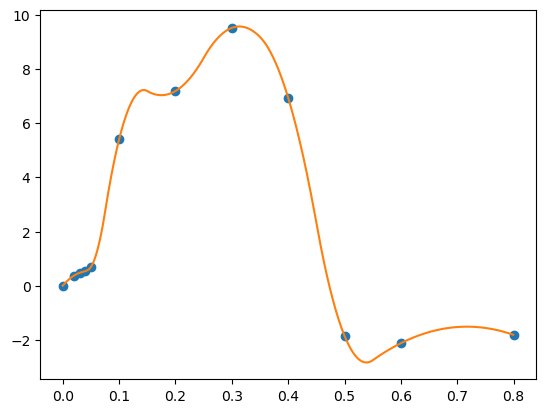

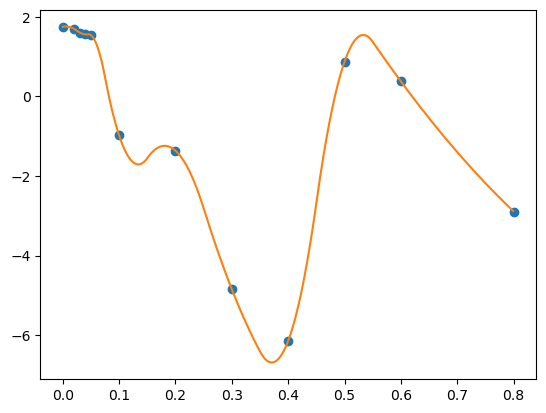

In [13]:
#TEST CELL FOR INTERPOLATION STUFF

brute_force_ecc_rates = list(changing_ecc_q_1.values())
brute_force_semi_rates = list(changing_semi_maj_q_1.values())
print(brute_force_ecc_rates)

brute_force_eccs = [0.00,0.02,0.03,0.04,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.80]
print(brute_force_eccs)

func_ecc = interpolate.interp1d(brute_force_eccs,brute_force_ecc_rates,kind='quadratic')
func_semi = interpolate.interp1d(brute_force_eccs,brute_force_semi_rates,kind='quadratic')

test_x = 0.02
test_y_ecc = func_ecc(test_x)
test_y_semi = func_semi(test_x)
print(test_y_ecc)
print(test_y_semi)

xnew = np.arange(0, 0.8, 0.001)
ynew1 = func_ecc(xnew)
ynew2 = func_semi(xnew)

# Eccentricity interpolation
plt.plot(brute_force_eccs, brute_force_ecc_rates, 'o', xnew, ynew1, '-')
plt.show()

# Semi-major axis interpolation
plt.plot(brute_force_eccs,brute_force_semi_rates, 'o', xnew, ynew2, '-')
plt.show()

**EVOLUTION FROM GAS**

In [14]:
seconds_to_years = 3.154e7
timestep_gas = np.linspace(0,500000000,10001)  # This timestep's already in units of "years", so no need to multiply by
q_init = 1.00                                  #  year_to_seconds (time from 0 to 100 million years in jumps of 10 000)

# Choose arbitrary semi-major axis value, like 0.5 AU for starters. If the simulation takes too long, reduce this. But first try
# and reach steady-state with evolution, until both eccentricity and semi-major reach 0 = merger of binary.


def param_evolution_gas(time):
    
    e_init = 0.02
    a_init = 0.2   # In units of AU
    y_vals_ecc = [e_init]
    y_vals_semi = [a_init]
    good_index = []
    num = 0
        
    brute_force_eccs = [0.00,0.02,0.03,0.04,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.80]
    brute_force_ecc_rates = list(changing_ecc_q_1.values())
    brute_force_semi_rates = list(changing_semi_maj_q_1.values())

    ecc_rate = evo_rate_conversion(ecc_evo_rate[0])
    semi_rate = evo_rate_conversion(semi_major_evo_rate[0])
    #print(ecc_rate)
    #print(semi_rate)
    #print(np.diff(timestep))
    
    while num < len(time)-1:
        for i in np.diff(time):
            #print(e_init)
            #print(a_init)
            if a_init > 0:
                e_init += (i*(ecc_rate*seconds_to_years))   # Here we multiply the rate by seconds_to_year to make sure all units
                a_init += (i*(semi_rate*seconds_to_years))  # of time are equivalent to years.
            if a_init <= 0:
                a_init = 0
                e_init = 0
            
            y_vals_ecc.append(e_init)
            y_vals_semi.append(a_init)
            #print(y_vals_ecc)
            #print(y_vals_semi)
            
            if e_init <= 0.8:
                ecc_rate_interpolator = interpolate.interp1d(brute_force_eccs,brute_force_ecc_rates,kind='quadratic')
                temp_rate_ecc = ecc_rate_interpolator(e_init)
                
                semi_rate_interpolator = interpolate.interp1d(brute_force_eccs,brute_force_semi_rates,kind='quadratic')
                temp_rate_semi = semi_rate_interpolator(e_init)
            else:
                temp_rate_ecc = list(changing_ecc_q_1.values())[11]      # This just sets the rate to the last one available in
                temp_rate_semi = list(changing_semi_maj_q_1.values())[11]# our data (which corresponds to the rate for e = 0.80)
                
            ecc_rate = evo_rate_conversion(temp_rate_ecc)    # This converts our updated evolution rate from units of
            semi_rate = evo_rate_conversion(temp_rate_semi)  # [Accretion Rate/Binary Mass] to [1/second]
            num += 1
            
    return y_vals_ecc, y_vals_semi


params_gas = param_evolution_gas(timestep_gas)

eccentricity_evolution_gas = params_gas[0]
#print(eccentricity_evolution_gas)
#print(len(eccentricity_evolution_gas))

semi_major_axis_evolution_gas = params_gas[1]   # Units of AU
#print(semi_major_axis_evolution_gas)
#print(len(semi_major_axis_evolution_gas))

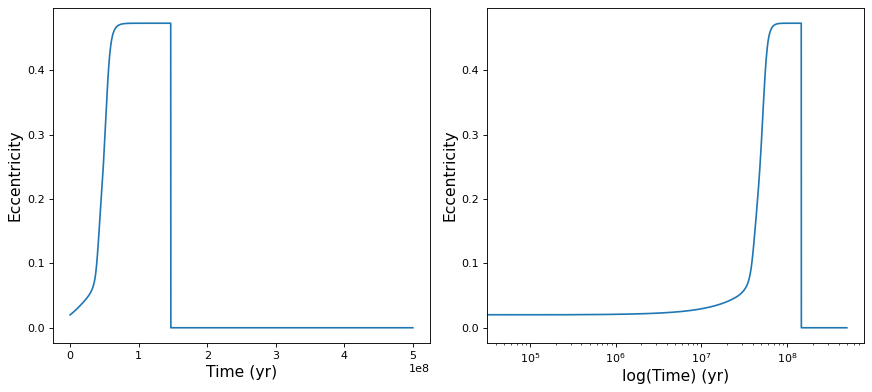

In [15]:
# For the Eccentricity (gas only)

figure(figsize=(11, 5), dpi=80)

plt.subplot(1, 2, 1)
plt.plot(timestep_gas, eccentricity_evolution_gas)
plt.xlabel('Time (yr)', fontsize=14)
plt.ylabel('Eccentricity',fontsize=14)

plt.subplot(1, 2, 2)
plt.semilogx(timestep_gas, eccentricity_evolution_gas)
plt.xlabel('log(Time) (yr)', fontsize=14)
plt.ylabel('Eccentricity', fontsize=14)

plt.tight_layout()
plt.show()

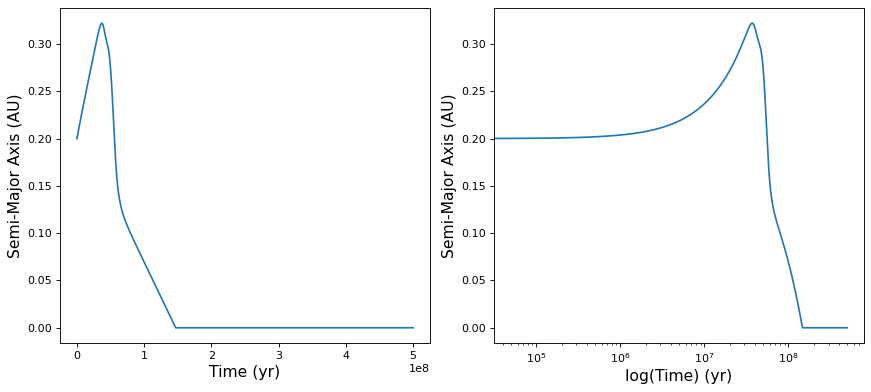

In [16]:
# For the Semi-Major Axis (gas only)

figure(figsize=(11, 5), dpi=80)

plt.subplot(1, 2, 1)
plt.plot(timestep_gas, semi_major_axis_evolution_gas)
plt.xlabel('Time (yr)', fontsize=14)
plt.ylabel('Semi-Major Axis (AU)', fontsize=14)

plt.subplot(1, 2, 2)
plt.semilogx(timestep_gas, semi_major_axis_evolution_gas)
plt.xlabel('log(Time) (yr)', fontsize=14)
plt.ylabel('Semi-Major Axis (AU)', fontsize=14)

plt.tight_layout()
plt.show()

**EVOLUTION FROM GW**

In [17]:
G = 6.67408e-11         # Universal gravitational constant (m^3 kg^-1 s^-2)
c = 299792458           # Speed of light in a vacuum (m s^1-)
sigma_T = 6.65246e-29   # Thomson cross-section of an electron (m^2)
m_p = 1.67262e-27       # Mass of a proton (kg)
edd_fraction = 0.1      # Chosen Eddington fraction (depends on astrophysical system used, CHECK WITH ISOBEL)
epsilon = 0.1           # Radiative efficiency, normally set to 0.1
Msol = 1.998e30         # Solar mass (kg)

year_to_seconds = 3.154e7
years_to_Gyr = 1e9
#timestep = np.linspace(0,100000000,10001)
timestep_GW = np.linspace(0,500000000000,5001)*year_to_seconds   # recall: this makes it still technically in units of seconds,
#timestep_GW = np.linspace(0,100000000000,1001)*years_to_Gyr     # but equivalent to years
q_init = 1.00
AU_to_m = 1.496e11

m1 = 30*Msol
m2 = m1*q_init
M = m1+m2
mu = (m1*m2)/M


def peters_semi(e,a):
    return (-64/5)*((G**3*mu*M**2)/(c**5*a**3*(1-e**2)**(7/2)))*(1+(73/24)*e**2+(37/96)*e**4)

def peters_ecc(e,a):
    return (-304/15)*e*((G**3*mu*M**2)/(c**5*a**4*(1-e**2)**(5/2)))*(1+(121/304)*e**2)



def param_evolution_GW(time):
    e_init = 0.02
    a_init = 0.2*AU_to_m
    
    y_vals_ecc = [e_init]
    y_vals_semi = [a_init]
    good_index = []
    num = 0
    time_count = 0
    
    brute_force_eccs = [0.00,0.02,0.03,0.04,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.80]
    brute_force_ecc_rates = list(changing_ecc_q_1.values())
    brute_force_semi_rates = list(changing_semi_maj_q_1.values())
    
    ecc_rate = evo_rate_conversion(ecc_evo_rate[0])
    semi_rate = evo_rate_conversion(semi_major_evo_rate[0])
    
    break_out_flag = False
    
    
    while num < len(time)-1:
        for i in np.diff(time):
            
            if a_init <= 0.02*AU_to_m:
                break_out_flag = True
                break
            
            if a_init > 0:
                e_init += (i*peters_ecc(e_init,a_init))
                a_init += (i*peters_semi(e_init,a_init))
            
            if a_init <= 0:
                a_init = 0
                e_init = 0
            
            y_vals_ecc.append(e_init)
            y_vals_semi.append(a_init)
            
            num += 1
            time_count += 1
            
        if break_out_flag:
            break
            
    num_new = 0
    time_new = np.linspace(time[time_count]/year_to_seconds,500000000000,10000001)*year_to_seconds
    
    while num_new < len(time_new)-1:
        for i in np.diff(time_new):
            
            if a_init > 0:
                e_init += (i*peters_ecc(e_init,a_init))
                a_init += (i*peters_semi(e_init,a_init))
            if a_init <= 0:
                e_init = 0
                a_init = 0
            
            if e_init > 1:
                num_new = len(time_new)-1
                break
            if e_init < 0:
                e_init = 0
            
            y_vals_ecc.append(e_init)
            y_vals_semi.append(a_init)
            
            num_new += 1
    
    
    return y_vals_ecc, y_vals_semi, time_count, time_new


params_GW = param_evolution_GW(timestep_GW)

eccentricity_evolution_GW = params_GW[0]
#print(eccentricity_evolution_GW)
#print(len(eccentricity_evolution_GW))

semi_major_axis_evolution_GW = params_GW[1]
semi_major_axis_evolution_GW = [x / AU_to_m for x in semi_major_axis_evolution_GW]
#print(semi_major_axis_evolution_GW)
#print(len(semi_major_axis_evolution_GW))


time_check_GW = params_GW[2]
#print(time_check_GW)

second_time_GW = params_GW[3]
second_time_GW = [x / year_to_seconds for x in second_time_GW]    # Convert time from units of seconds to years
second_time_GW = [x / years_to_Gyr for x in second_time_GW]       # Convert from units of years to gigayears



timestep_GW_plot = [x / year_to_seconds for x in timestep_GW]   # This is to put the time back to units of years for plotting
timestep_GW_plot = [x / years_to_Gyr for x in timestep_GW_plot]   # Same process, but to convert to Gigayears

In [18]:
#jupyter notebook --NotebookApp.iopub_data_rate_limit=1.0e10

M_binary = 60
GW_only_frequency = []
for i in semi_major_axis_evolution_GW:
    if i > 0:
        GW_only_frequency.append(GW_freq_calc(i,M_binary))
    if i <= 0:
        GW_only_frequency.append(0)
    #print(len(GW_only_frequency))

print(GW_only_frequency)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [19]:
first_time_part_GW = timestep_GW_plot[0:time_check_GW]
#print(first_time_part_GW)
#print(len(first_time_part_GW))

second_time_part_GW = second_time_GW
#print(second_time_part_GW)
#print(len(second_time_part_GW))

total_time_GW = np.concatenate([first_time_part_GW,second_time_part_GW])
print(total_time_GW)
print(len(total_time_GW))

[0.00000000e+00 1.00000000e-01 2.00000000e-01 ... 4.99999902e+02
 4.99999951e+02 5.00000000e+02]
10000098


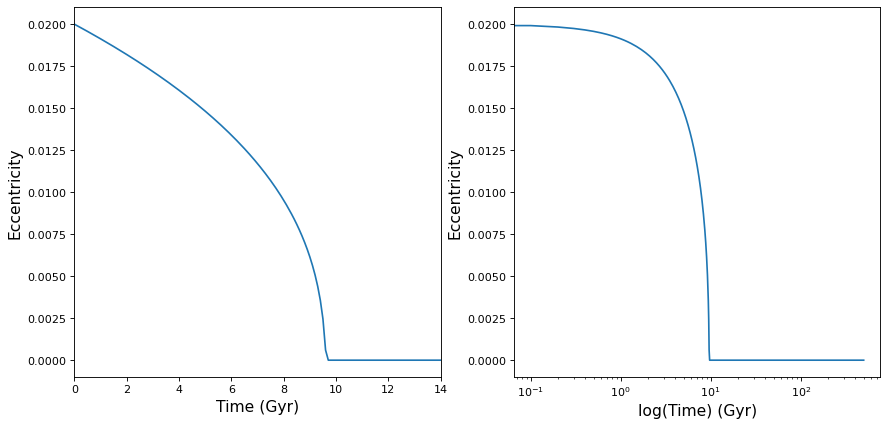

In [20]:
# For the Eccentricity (GW)

figure(figsize=(13, 6), dpi=80)

plt.subplot(1, 2, 1)
plt.plot(total_time_GW, eccentricity_evolution_GW)
#plt.plot(timestep_GW_plot, eccentricity_evolution_gas_GW)
plt.xlim(0,14)
plt.xlabel('Time (Gyr)', fontsize=14)
plt.ylabel('Eccentricity',fontsize=14)

plt.subplot(1,2,2)
#plt.plot(timestep_GW_plot, eccentricity_evolution_GW)
plt.semilogx(total_time_GW, eccentricity_evolution_GW)
plt.xlabel('log(Time) (Gyr)', fontsize=14)
plt.ylabel('Eccentricity', fontsize=14)
plt.show()

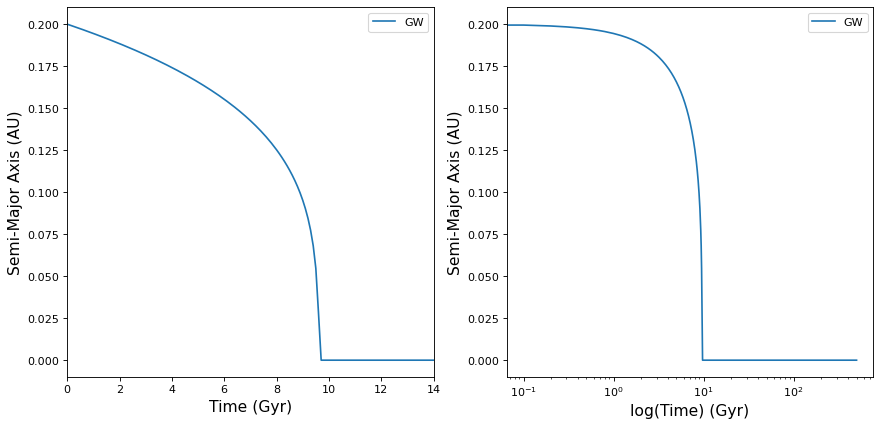

In [21]:
# For the Semi-Major Axis (GW)

figure(figsize=(13, 6), dpi=80)

plt.subplot(1, 2, 1)
plt.plot(total_time_GW, semi_major_axis_evolution_GW, label = 'GW')
plt.xlim(0,14)
plt.xlabel('Time (Gyr)', fontsize=14)
plt.ylabel('Semi-Major Axis (AU)', fontsize=14)
plt.legend()

plt.subplot(1, 2, 2)
#plt.plot(timestep_GW_plot, semi_major_axis_evolution_gas, label = 'gas')
plt.semilogx(total_time_GW, semi_major_axis_evolution_GW, label = 'GW')
plt.xlabel('log(Time) (Gyr)', fontsize=14)
plt.ylabel('Semi-Major Axis (AU)', fontsize=14)
plt.legend()
plt.show()

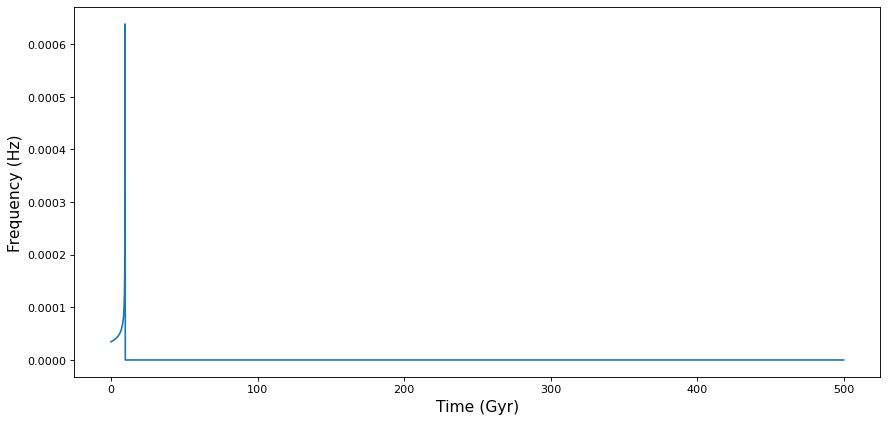

In [22]:
# For the GW's frequency

figure(figsize=(13, 6), dpi=80)

#plt.subplot(1, 2, 1)
plt.plot(total_time_GW, GW_only_frequency, label = 'GW')
#plt.xlim(0,14)
plt.xlabel('Time (Gyr)', fontsize=14)
plt.ylabel('Frequency (Hz)', fontsize=14)

#plt.subplot(1, 2, 2)
#plt.semilogx(timestep_GW_plot, GW_only_frequency, label = 'GW')
#plt.xlim(0,14)
plt.xlabel('Time (Gyr)', fontsize=14)
plt.ylabel('Frequency (Hz)', fontsize=14)
plt.show()

**EVOLUTION FROM GAS & GW**

In [23]:
np.linspace(251,40001,1001)

array([  251.  ,   290.75,   330.5 , ..., 39921.5 , 39961.25, 40001.  ])

In [24]:
G = 6.67408e-11         # Universal gravitational constant (m^3 kg^-1 s^-2)
c = 299792458           # Speed of light in a vacuum (m s^1-)
sigma_T = 6.65246e-29   # Thomson cross-section of an electron (m^2)
m_p = 1.67262e-27       # Mass of a proton (kg)
edd_fraction = 0.1      # Chosen Eddington fraction (depends on astrophysical system used, CHECK WITH ISOBEL)
epsilon = 0.1           # Radiative efficiency, normally set to 0.1
Msol = 1.998e30         # Solar mass (kg)

year_to_seconds = 3.154e7
years_to_Gyr = 1e9
timestep_gas_GW = np.linspace(0,2500000000,251)*year_to_seconds # I convert to seconds to match units of time later on in code

#timestep_gas_GW = np.linspace(0,10000000,101)*year_to_seconds # units of years. Increase timestep to see ecentricity changes
#timestep_gas_GW = linspace(0,1000,101)  #in units of Gyrs
q_init = 1.00
AU_to_m = 1.496e11
m1 = 30*Msol
m2 = m1*q_init
M = 60*Msol
mu = (m1*m2)/M


def peters_semi(e,a):
    return (-64/5)*((G**3*mu*M**2)/(c**5*a**3*(1-e**2)**(7/2)))*(1+(73/24)*e**2+(37/96)*e**4)

def peters_semi_v2(e,a):
    return (-64/5)*((G**3*mu*M**2)/(c**5*(a*AU_to_m)**3*(1-e**2)**(7/2)))*(1+(73/24)*e**2+(37/96)*e**4)

def peters_ecc(e,a):
    return (-304/15)*e*((G**3*mu*M**2)/(c**5*a**4*(1-e**2)**(5/2)))*(1+(121/304)*e**2)


def updating_time():
    updated_timestep = np.linspace(251,40001,10001)

    
    

def param_evolution_gas_GW(time):
    y_vals_ecc = []
    y_vals_semi = []
    good_index = []
    num = 0
    time_count = 0
        
    brute_force_eccs = [0.00,0.02,0.03,0.04,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.80]
    brute_force_ecc_rates = list(changing_ecc_q_1.values())
    brute_force_semi_rates = list(changing_semi_maj_q_1.values())
    
    e_init = 0.02
    #a_init = 0.5
    a_init = 0.2*AU_to_m
    ecc_rate = evo_rate_conversion(ecc_evo_rate[0])
    semi_rate = evo_rate_conversion(semi_major_evo_rate[0])
    
    y_vals_ecc.append(e_init)
    y_vals_semi.append(a_init)
    
    
    dt1_ecc = [ecc_rate]
    dt2_ecc = [peters_ecc(e_init,a_init)]
    dt1_semi = [semi_rate]
    dt2_semi = [peters_semi(e_init,a_init)]
    
    break_out_flag = False
    
    
    while num < len(time)-1:
        for i in np.diff(time):
            #print(e_init)
            #print(a_init)
                
            #print(a_init)
            if a_init <= 0.02*AU_to_m:
                break_out_flag = True
                break
            
            if a_init > 0:
                e_init += (i*(ecc_rate))+(i*peters_ecc(e_init,a_init))    # NOTE: evo rates are in units of 1/second
                a_init += (i*(semi_rate))+(i*peters_semi(e_init,a_init))
            if a_init <= 0:
                e_init = 0
                a_init = 0
            
            if e_init > 1:
                num = len(time)-1
                break
            if e_init < 0:
                e_init = 0
                
            y_vals_ecc.append(e_init)
            y_vals_semi.append(a_init)
            
            if a_init > 0:
                dt1_ecc.append(i*(ecc_rate))
                dt2_ecc.append(i*peters_ecc(e_init,a_init))
                dt1_semi.append(i*(semi_rate))
                dt2_semi.append(i*peters_semi(e_init,a_init))
            if a_init <=0:
                dt1_ecc.append(0)
                dt2_ecc.append(0)
                dt1_semi.append(0)
                dt2_semi.append(0)
            
            
            #print(e_init)
            if e_init <= 0.8:
                ecc_rate_interpolator = interpolate.interp1d(brute_force_eccs,brute_force_ecc_rates,kind='quadratic')
                temp_rate_ecc = ecc_rate_interpolator(e_init)
                
                semi_rate_interpolator = interpolate.interp1d(brute_force_eccs,brute_force_semi_rates,kind='quadratic')
                temp_rate_semi = semi_rate_interpolator(e_init)
            else:
                temp_rate_ecc = list(changing_ecc_q_1.values())[11]     
                temp_rate_semi = list(changing_semi_maj_q_1.values())[11]
                
            ecc_rate = evo_rate_conversion(temp_rate_ecc)
            semi_rate = evo_rate_conversion(temp_rate_semi)
            num += 1
            time_count += 1
        
        if break_out_flag:
            break
    
    
    num_new = 0
    time_new = np.linspace(time[time_count]/year_to_seconds,2500000000,40001)*year_to_seconds    # try np.logspace()?
    
    # How do I set up np.logspace() properly so that large numbers don't mess it up
    
    
    while num_new < len(time_new)-1:
        for i in np.diff(time_new):
            
            if a_init > 0:
                e_init += (i*peters_ecc(e_init,a_init))
                a_init += (i*peters_semi(e_init,a_init))
                
                #e_init += (i*(ecc_rate))+(i*peters_ecc(e_init,a_init))       # I'm not considering the gas part of the evo,
                #a_init += (i*(semi_rate))+(i*peters_semi(e_init,a_init))     # since at this point the GW effect is much more 
                                                                              # relevant.
            if a_init <= 0:
                e_init = 0
                a_init = 0
            
            y_vals_ecc.append(e_init)
            y_vals_semi.append(a_init)
            
            if a_init > 0:
                dt1_ecc.append(i*(ecc_rate))
                dt2_ecc.append(i*peters_ecc(e_init,a_init))
                dt1_semi.append(i*(semi_rate))
                dt2_semi.append(i*peters_semi(e_init,a_init))
            if a_init <=0:
                dt1_ecc.append(0)
                dt2_ecc.append(0)
                dt1_semi.append(0)
                dt2_semi.append(0)
            
            
            if e_init > 1:
                num_new = len(time_new)-1
                break
            if e_init < 0:
                e_init = 0
            
            #print(e_init)
            if e_init <= 0.8:
                ecc_rate_interpolator = interpolate.interp1d(brute_force_eccs,brute_force_ecc_rates,kind='quadratic')
                temp_rate_ecc = ecc_rate_interpolator(e_init)
                
                semi_rate_interpolator = interpolate.interp1d(brute_force_eccs,brute_force_semi_rates,kind='quadratic')
                temp_rate_semi = semi_rate_interpolator(e_init)
            else:
                temp_rate_ecc = list(changing_ecc_q_1.values())[11]     
                temp_rate_semi = list(changing_semi_maj_q_1.values())[11]
                
            ecc_rate = evo_rate_conversion(temp_rate_ecc)
            semi_rate = evo_rate_conversion(temp_rate_semi)
            num_new += 1
    
    
    return y_vals_ecc, y_vals_semi, dt1_ecc, dt2_ecc, dt1_semi, dt2_semi, time_count, time_new


params_gas_GW = param_evolution_gas_GW(timestep_gas_GW)


eccentricity_evolution_gas_GW = params_gas_GW[0]
#print(eccentricity_evolution_gas_GW)
#print(len(eccentricity_evolution_gas_GW))

semi_major_axis_evolution_gas_GW = params_gas_GW[1]
semi_major_axis_evolution_gas_GW = [x / AU_to_m for x in semi_major_axis_evolution_gas_GW]
#print(semi_major_axis_evolution_gas_GW)
#print(len(semi_major_axis_evolution_gas))

eccentricity_dt_gas = params_gas_GW[2]
#print(eccentricity_dt_gas)
#print(len(eccentricity_dt_gas))

eccentricity_dt_GW = params_gas_GW[3]
#print(eccentricity_dt_GW)
#print(len(eccentricity_dt_GW))

semi_major_dt_gas = params_gas_GW[4]
#print(semi_major_dt_gas)
#print(len(semi_major_dt_gas))

semi_major_dt_GW = params_gas_GW[5]
#print(semi_major_dt_GW)
#print(len(semi_major_dt_GW))

time_check = params_gas_GW[6]
#print(time_check)

second_time = params_gas_GW[7]
second_time = [x / year_to_seconds for x in second_time]    # Convert time from units of seconds to years
second_time = [x / years_to_Gyr for x in second_time]  # Convert from units of years to gigayears



timestep_gas_GW_plot = [x / year_to_seconds for x in timestep_gas_GW]    # Convert time from units of seconds to years
timestep_gas_GW_plot = [x / years_to_Gyr for x in timestep_gas_GW_plot]  # Convert from units of years to gigayears

In [32]:
print(semi_major_axis_evolution_gas_GW)

[0.2, 0.199946447442587, 0.1998926124265637, 0.19983837048501943, 0.19978344917050075, 0.19972622514637303, 0.19965179481140774, 0.19950650439960513, 0.199122093844026, 0.19886687592484675, 0.19866084997698477, 0.19841573112540944, 0.19820480145264738, 0.19796348947414383, 0.19774864704321557, 0.1975091638130744, 0.1972909437410552, 0.1970522881617972, 0.19683103030985696, 0.19659258982034702, 0.19636853000336352, 0.1961298863457763, 0.195903197084796, 0.1956640432383861, 0.19543485480028364, 0.19519495352511174, 0.19496336593158198, 0.1947225267618514, 0.19448861719585298, 0.19424668261673855, 0.19401051029311064, 0.1937673468965153, 0.19352895644640525, 0.19328444897276378, 0.19304387290945707, 0.19279792005668303, 0.19255518064509264, 0.19230769201113984, 0.19206280273147813, 0.1918136965142258, 0.19156666323670082, 0.19131586445822402, 0.19106668640305394, 0.19081412550866367, 0.19056279604046752, 0.19030840777313177, 0.19005491506341202, 0.1897986375454419, 0.1895429651273034, 0.1

In [26]:
M_binary = 60
GW_gas_frequency = []
for i in semi_major_axis_evolution_gas_GW:
    if i > 0:
        placeholder = GW_freq_calc(i,M_binary)
        GW_gas_frequency.append(placeholder)
    if i <= 0:
        GW_gas_frequency.append(0)

#print(GW_gas_frequency)
#print(len(GW_gas_frequency))

In [27]:
first_time_part = timestep_gas_GW_plot[0:time_check]
#print(first_time_part)
#print(len(first_time_part))

second_time_part = second_time
#print(second_time_part)
#print(len(second_time_part))

total_time_gas_GW = np.concatenate([first_time_part,second_time_part])
print(total_time_gas_GW)
print(len(total_time_gas_GW))

[0.         0.01       0.02       ... 2.4999935  2.49999675 2.5       ]
40238


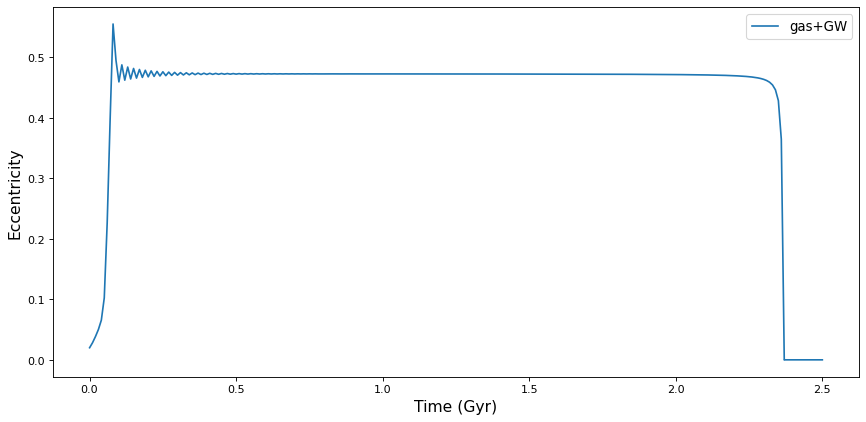

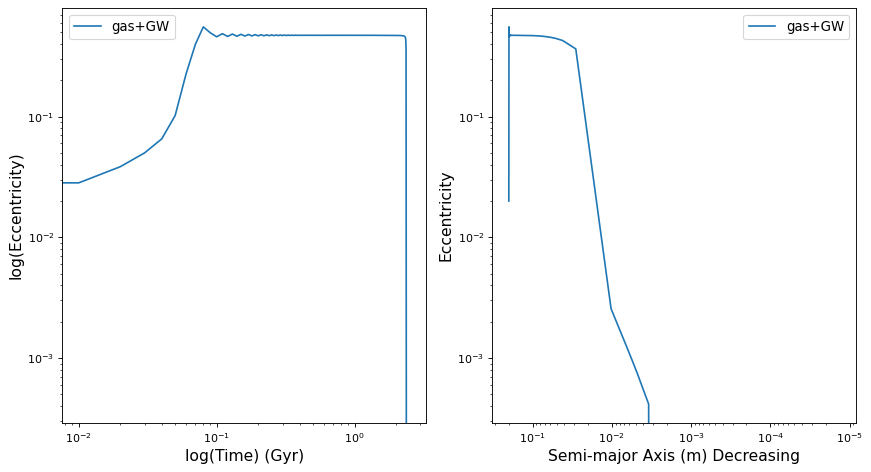

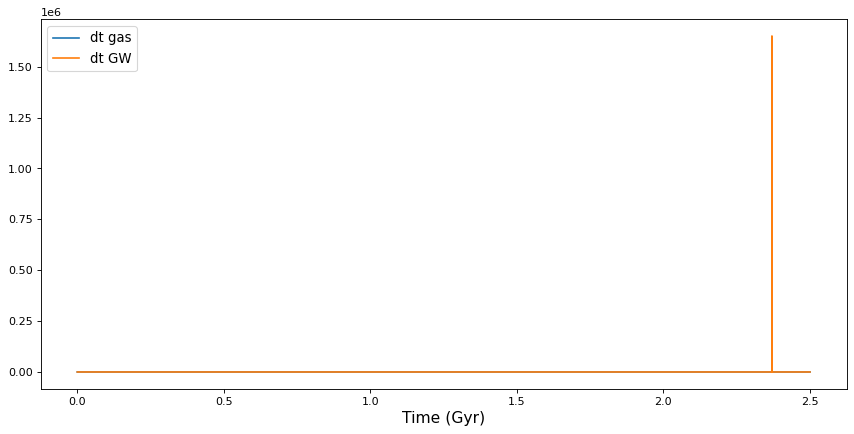

In [28]:
# For the Eccentricity (gas & GW)

figure(figsize=(13, 6), dpi=80)

plt.plot(total_time_gas_GW, eccentricity_evolution_gas_GW, label='gas+GW')
plt.xlabel('Time (Gyr)', fontsize=14)
plt.ylabel('Eccentricity',fontsize=14)
plt.legend(fontsize=12)
plt.show()


figure(figsize=(11, 6), dpi=80)

plt.subplot(1, 2, 1)
#plt.plot(timestep_gas_GW_plot, eccentricity_evolution_gas, label='gas')
plt.loglog(total_time_gas_GW, eccentricity_evolution_gas_GW, label='gas+GW')
plt.xlabel('log(Time) (Gyr)', fontsize=14)
plt.ylabel('log(Eccentricity)',fontsize=14)
plt.legend(fontsize=12)

plt.subplot(1,2,2)
#plt.plot(timestep_gas_GW_plot, eccentricity_evolution_gas, label='gas')
plt.loglog(semi_major_axis_evolution_gas_GW, eccentricity_evolution_gas_GW, label='gas+GW')
plt.gca().invert_xaxis()
plt.xlabel('Semi-major Axis (m) Decreasing', fontsize=14)
plt.ylabel('Eccentricity', fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()




figure(figsize=(13, 6), dpi=80)
#plt.subplot(1, 2, 1)
plt.plot(total_time_gas_GW, eccentricity_dt_gas, label='dt gas')
plt.plot(total_time_gas_GW, eccentricity_dt_GW, label='dt GW')
plt.xlabel('Time (Gyr)', fontsize=14)
plt.legend(fontsize=12)

plt.show()

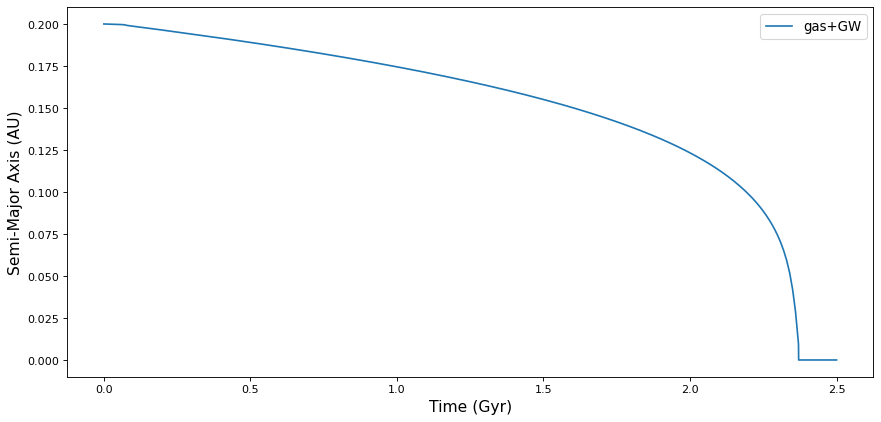

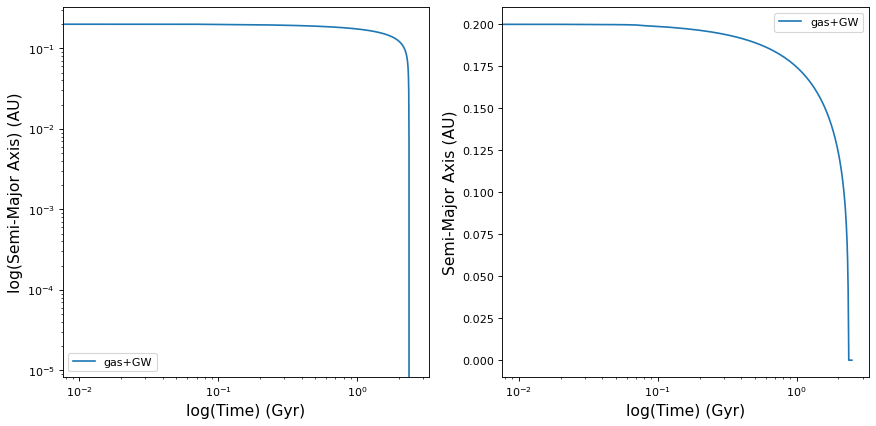

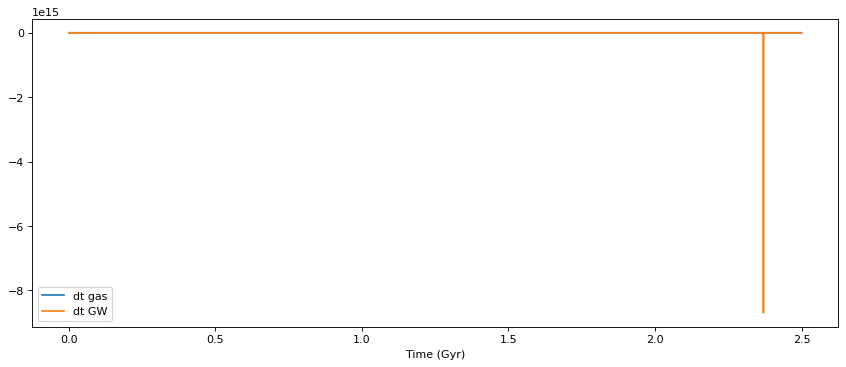

In [29]:
# For the Semi-Major Axis (gas & GW)


figure(figsize=(13, 6), dpi=80)

plt.plot(total_time_gas_GW, semi_major_axis_evolution_gas_GW, label='gas+GW')
plt.xlabel('Time (Gyr)', fontsize=14)
plt.ylabel('Semi-Major Axis (AU)',fontsize=14)
plt.legend(fontsize=12)
plt.show()


figure(figsize=(13, 6), dpi=80)

plt.subplot(1, 2, 1)
#plt.plot(timestep_gas_GW_plot, semi_major_axis_evolution_gas, label = 'gas')
plt.loglog(total_time_gas_GW, semi_major_axis_evolution_gas_GW, label = 'gas+GW')
plt.xlabel('log(Time) (Gyr)', fontsize=14)
plt.ylabel('log(Semi-Major Axis) (AU)', fontsize=14)
plt.legend()

plt.subplot(1,2,2)
#plt.plot(timestep_gas_GW_plot, semi_major_axis_evolution_gas, label = 'gas')
plt.semilogx(total_time_gas_GW, semi_major_axis_evolution_gas_GW, label = 'gas+GW')
plt.xlabel('log(Time) (Gyr)', fontsize=14)
plt.ylabel('Semi-Major Axis (AU)', fontsize=14)
plt.legend()
plt.show()


figure(figsize=(13, 5), dpi=80)
plt.plot(total_time_gas_GW, semi_major_dt_gas, label='dt gas')
plt.plot(total_time_gas_GW, semi_major_dt_GW, label='dt GW')
plt.xlabel("Time (Gyr)")
#plt.xlim(-0.005e10,0.08e10)
plt.legend()
plt.show()

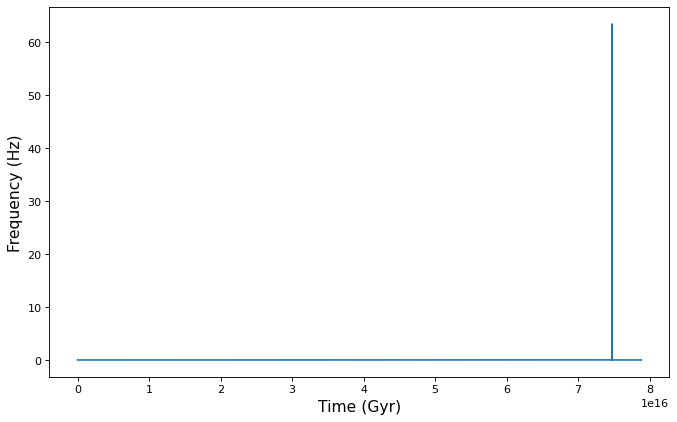

In [30]:
# For the gas+GW's frequency

freq_time = [x * years_to_Gyr for x in total_time_gas_GW]    # Convert time from units of gigayears to years
freq_time = [x * year_to_seconds for x in freq_time]        # Convert time from units of years to seconds


figure(figsize=(10, 6), dpi=80)

#print(semi_major_axis_evolution_gas_GW)
#print(GW_gas_frequency)

#plt.plot(total_time_gas_GW, GW_gas_frequency, label = 'GW')
plt.plot(freq_time, GW_gas_frequency, label = 'GW')
plt.xlabel('Time (Gyr)', fontsize=14)
plt.ylabel('Frequency (Hz)', fontsize=14)
#plt.xlim(7.47e16,7.48e16)
plt.show()

In [31]:
print("timestep: {} s".format(second_time_part[1] - second_time_part[0]))

timestep: 3.2499999997881446e-06 s
